In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

In [9]:
# Define Logistic Regression from scratch
class LogRegression:
  def __init__(self, lr=0.01, n_iter=1000):
    self.lr = lr
    self.n_iter = n_iter
    self.weights = None
    self.bias = None


  def sigmoid(self, z):
    # Sigmoid activation function
    return 1 / (1 + np.exp(-z))


  def fit(self, X, y):
    # Initialize parameters
    n_samples, n_features = X.shape
    self.weights = np.zeros((n_features, 1))
    self.bias = 0
    self.losses = [] # To track loss per iteration


  # Gradient Descent
    for i in range(self.n_iter):
      # Linear model
      linear_model = np.dot(X, self.weights) + self.bias
      y_pred = self.sigmoid(linear_model)
      # Compute gradients
      dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
      db = (1 / n_samples) * np.sum(y_pred - y)
      # Update parameters
      self.weights -= self.lr * dw
      self.bias -= self.lr * db
      # Compute and store loss (binary cross-entropy)
      loss = - (1 / n_samples) * np.sum(y * np.log(y_pred + 1e-8) + (1 - y) * np.log(1 - y_pred + 1e-8))
      self.losses.append(loss)
      if i % 100 == 0:
        print(f'Iteration {i}: Loss = {loss:.4f}')


  def predict_proba(self, X):
    # Predict probabilities
    return self.sigmoid(np.dot(X, self.weights) + self.bias)


  def predict(self, X):
    # Predict binary outcomes
    y_pred_proba = self.predict_proba(X)
    return (y_pred_proba >= 0.5).astype(int)

In [41]:
# Load Dataset
df = pd.read_csv('./../Data/processed_scaled_diabetes.csv')
print('Shape:', df.shape)
print(df.head())

Shape: (768, 9)
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.865108      -0.033518       0.670643 -0.181541  0.166619   
1    -0.844885 -1.206162      -0.529859      -0.012301 -0.181541 -0.852200   
2     1.233880  2.015813      -0.695306      -0.012301 -0.181541 -1.332500   
3    -0.844885 -1.074652      -0.529859      -0.695245 -0.540642 -0.633881   
4    -1.141852  0.503458      -2.680669       0.670643  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.468492  1.425995        1  
1                 -0.365061 -0.190672        0  
2                  0.604397 -0.105584        1  
3                 -0.920763 -1.041549        0  
4                  5.484909 -0.020496        1  


In [ ]:
# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values.reshape(-1, 1)

In [16]:
# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [19]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Train model
model = LogRegression(lr=0.01, n_iter=2000)
model.fit(X_train, y_train)

Iteration 0: Loss = 0.6931
Iteration 100: Loss = 0.5893
Iteration 200: Loss = 0.5437
Iteration 300: Loss = 0.5194
Iteration 400: Loss = 0.5047
Iteration 500: Loss = 0.4949
Iteration 600: Loss = 0.4880
Iteration 700: Loss = 0.4829
Iteration 800: Loss = 0.4791
Iteration 900: Loss = 0.4761
Iteration 1000: Loss = 0.4737
Iteration 1100: Loss = 0.4718
Iteration 1200: Loss = 0.4702
Iteration 1300: Loss = 0.4689
Iteration 1400: Loss = 0.4679
Iteration 1500: Loss = 0.4670
Iteration 1600: Loss = 0.4662
Iteration 1700: Loss = 0.4656
Iteration 1800: Loss = 0.4651
Iteration 1900: Loss = 0.4646


In [21]:
# Evaluate model
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f'\nModel Accuracy on Test Data: {accuracy * 100:.2f}%')


Model Accuracy on Test Data: 75.97%


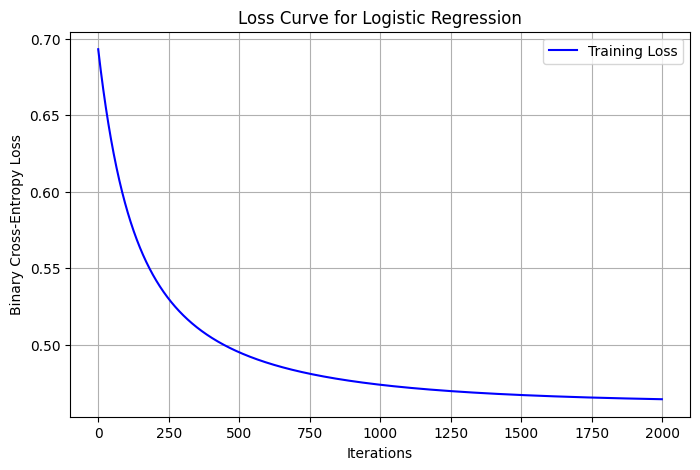

In [22]:
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(model.losses, label='Training Loss', color='blue')
plt.title('Loss Curve for Logistic Regression')
plt.xlabel('Iterations')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Confusion Matrix
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))


print('\nConfusion Matrix:')
print(f'TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}')


Confusion Matrix:
TP: 34, TN: 83, FP: 16, FN: 21


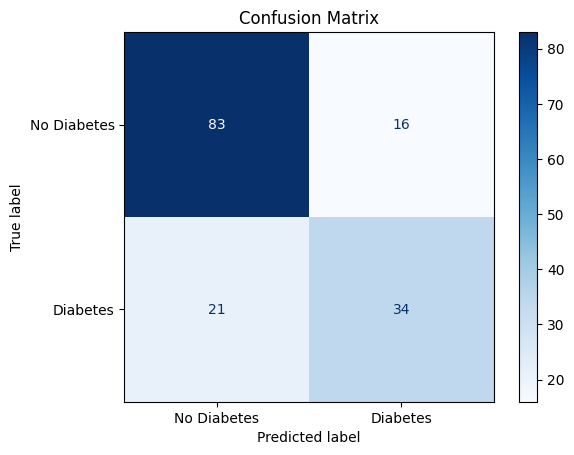

In [28]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


In [43]:

# Load Dataset
df2 = df.drop('SkinThickness', axis=1)
print(df2.head())

   Pregnancies   Glucose  BloodPressure   Insulin       BMI  \
0     0.639947  0.865108      -0.033518 -0.181541  0.166619   
1    -0.844885 -1.206162      -0.529859 -0.181541 -0.852200   
2     1.233880  2.015813      -0.695306 -0.181541 -1.332500   
3    -0.844885 -1.074652      -0.529859 -0.540642 -0.633881   
4    -1.141852  0.503458      -2.680669  0.316566  1.549303   

   DiabetesPedigreeFunction       Age  Outcome  
0                  0.468492  1.425995        1  
1                 -0.365061 -0.190672        0  
2                  0.604397 -0.105584        1  
3                 -0.920763 -1.041549        0  
4                  5.484909 -0.020496        1  


In [44]:
# Split features and target
X = df2.drop('Outcome', axis=1).values
y = df2['Outcome'].values.reshape(-1, 1)

In [48]:
# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [49]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [50]:
# Train model
model = LogRegression(lr=0.01, n_iter=2000)
model.fit(X_train, y_train)

Iteration 0: Loss = 0.6931
Iteration 100: Loss = 0.5931
Iteration 200: Loss = 0.5464
Iteration 300: Loss = 0.5208
Iteration 400: Loss = 0.5050
Iteration 500: Loss = 0.4944
Iteration 600: Loss = 0.4869
Iteration 700: Loss = 0.4814
Iteration 800: Loss = 0.4772
Iteration 900: Loss = 0.4739
Iteration 1000: Loss = 0.4713
Iteration 1100: Loss = 0.4692
Iteration 1200: Loss = 0.4674
Iteration 1300: Loss = 0.4660
Iteration 1400: Loss = 0.4648
Iteration 1500: Loss = 0.4639
Iteration 1600: Loss = 0.4630
Iteration 1700: Loss = 0.4623
Iteration 1800: Loss = 0.4618
Iteration 1900: Loss = 0.4613


In [51]:
# Evaluate model
y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f'\nModel Accuracy on Test Data: {accuracy * 100:.2f}%')


Model Accuracy on Test Data: 76.62%


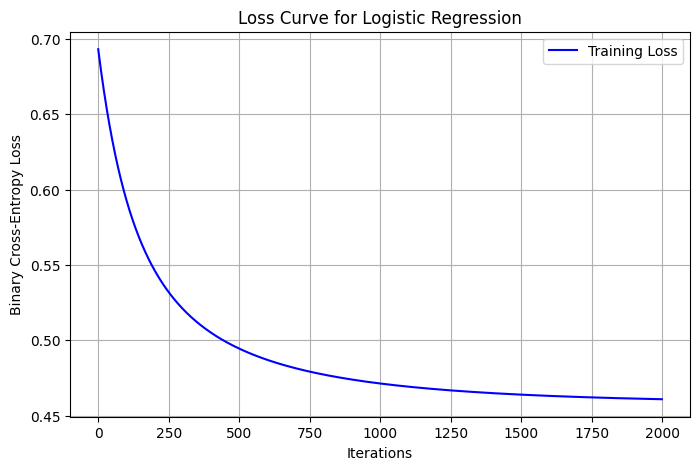

In [52]:
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(model.losses, label='Training Loss', color='blue')
plt.title('Loss Curve for Logistic Regression')
plt.xlabel('Iterations')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

In [53]:
# Confusion Matrix
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))


print('\nConfusion Matrix:')
print(f'TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}')


Confusion Matrix:
TP: 29, TN: 89, FP: 15, FN: 21


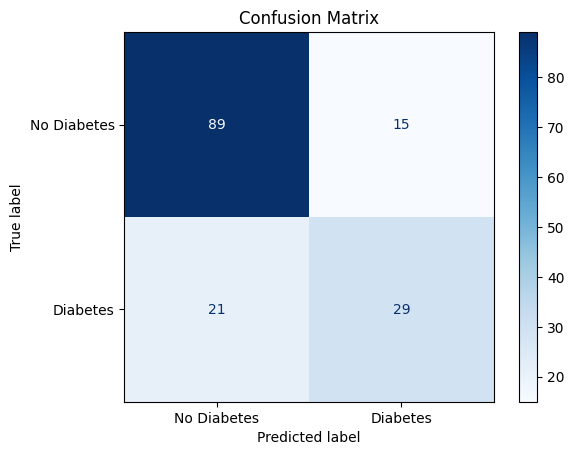

In [54]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()
